In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler


In [6]:
a=pd.read_csv("student-por.csv")
a

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [7]:
x=a['age']
x

,age
0,18
1,17
2,15
3,15
4,16
...,...
644,19
645,18
646,18
647,17


In [8]:
y=a['Mjob']
y

,Mjob
0,at_home
1,at_home
2,at_home
3,health
4,other
...,...
644,services
645,teacher
646,other
647,services


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [16]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train.values.reshape(-1,1))
x_test=scaler.transform(x_test.values.reshape(-1,1))

In [17]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [22]:
accuracy=model.score(x_test,y_test)
print("Accuracy:",accuracy)
print("Accuracy:",accuracy*100,"%")


Accuracy: 0.35384615384615387
Accuracy: 35.38461538461539 %


In [26]:
age=int(input("Enter the age:"))
user=pd.DataFrame([[age]],columns=["age"])
user_scaled=scaler.transform(user)
prediction=model.predict(user_scaled)
print("Predicted Job:",prediction[0])

Enter the age:20
Predicted Job: other


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


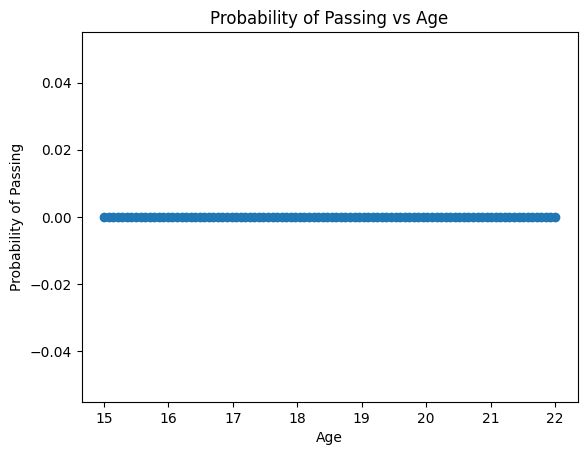

In [59]:
x_range_scaled=scaler.transform(x_range.reshape(-1,1))
y_prob=model.predict_proba(x_range_scaled)[:,1]
plt.scatter(x_range,y_prob)
plt.xlabel("Age")
plt.ylabel("Probability of Passing")
plt.title("Probability of Passing vs Age")
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score

In [41]:
b=pd.read_csv("Social_Network_Ads.csv")
b

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [48]:
x=b[['Age']]
x

,Age
0,19
1,35
2,26
3,27
4,19
...,...
395,46
396,51
397,50
398,36


In [47]:
y=b[["EstimatedSalary"]]
y

,EstimatedSalary
0,19000
1,20000
2,43000
3,57000
4,76000
...,...
395,41000
396,23000
397,20000
398,33000


In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [50]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [54]:
age=int(input("Enter the age:"))
inputes=pd.DataFrame([[age]], columns=['Age'])
print(model.predict(inputes))

Enter the age:20
[82000]


In [56]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,scoring='accuracy')
print("average accuracy=",scores.mean())

average accuracy= 0.025


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.